In [1]:
# correlations across k3 conditions
# try z-score normalization and clustering/large deviations (normal distributions?)

In [1]:
import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib
from itertools import combinations
import numpy as np

In [2]:
# figure save directory
save_dir = "../../img/k3-conditions"
os.makedirs(save_dir, exist_ok=True)

In [3]:
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

In [4]:
k3_conditions = ['VACV K3', 'K3Δ58', 'RCVZ vIF2α', 'VARV C3','MYXV M156R','TPV K3']
k3_combinations = list(combinations(k3_conditions, 2))
k3_combinations

[('VACV K3', 'K3Δ58'),
 ('VACV K3', 'RCVZ vIF2α'),
 ('VACV K3', 'VARV C3'),
 ('VACV K3', 'MYXV M156R'),
 ('VACV K3', 'TPV K3'),
 ('K3Δ58', 'RCVZ vIF2α'),
 ('K3Δ58', 'VARV C3'),
 ('K3Δ58', 'MYXV M156R'),
 ('K3Δ58', 'TPV K3'),
 ('RCVZ vIF2α', 'VARV C3'),
 ('RCVZ vIF2α', 'MYXV M156R'),
 ('RCVZ vIF2α', 'TPV K3'),
 ('VARV C3', 'MYXV M156R'),
 ('VARV C3', 'TPV K3'),
 ('MYXV M156R', 'TPV K3')]

In [6]:
df.query('pkr == "PKR-WT"')

,k3,pkr,auc_mean,auc_std,auc_sem,pkr_bc_nunique,0hr_total_reads,site,pkr_regions,pkr_type,...,wt_cat,var_cat,isr_kinase_conservation,elde_primate_positive_selection,vertebrate_positive_selection,pkr_conservation,jaquet_primate_positive_selection,vert_sele_analysis,elde_primate_sele_analysis,jaquet_primate_sele_analysis
418,K3Δ58,PKR-WT,4.581989,1.674691,0.094060,317,52512.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849,MYXV M156R,PKR-WT,5.055724,1.199992,0.068599,306,77685.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1280,RCVZ vIF2α,PKR-WT,1.431478,0.851817,0.046196,340,63495.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1711,TPV K3,PKR-WT,0.010455,0.772814,0.040959,356,89861.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2142,VACV K3,PKR-WT,3.953782,1.224256,0.074231,272,62756.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2573,VARV C3,PKR-WT,1.901769,1.573944,0.086774,329,54508.0,NaN,NaN,WT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Conditions: WT K3 versus K3Δ58
temp_df = df
temp_df = temp_df.pivot_table(index=['pkr'], columns='k3', values='auc_mean', fill_value=np.nan).reset_index()
temp_df

k3,pkr,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3
0,PKR-A488D,4.426750,4.622081,2.577393,5.311221,0.097070,2.022858
1,PKR-A488G,4.936558,4.682046,2.634514,3.199351,6.353255,4.779592
2,PKR-A488P,-6.406692,-6.609454,-3.130455,0.054919,-4.674444,-2.246141
3,PKR-A488S,3.914160,4.925366,3.914236,0.164917,3.198287,3.129209
4,PKR-A488T,3.998408,5.154235,5.995610,0.006179,1.126693,1.101969
...,...,...,...,...,...,...,...
426,PKR-Y454D,-6.766285,-7.115952,-3.910259,-1.159660,-5.334014,-2.896493
427,PKR-Y454F,4.431699,5.008676,0.513294,1.824501,5.465400,3.070823
428,PKR-Y454H,3.803048,4.194004,0.133976,5.298475,2.793520,2.821208
429,PKR-Y454N,-4.153721,-4.352082,-3.632787,0.712506,-3.237573,-1.960642


In [8]:
temp_df = pd.merge(temp_df, df[['pkr','pkr_type','site','wt_cat','var_cat']], on='pkr', how='left')
temp_df.drop_duplicates(inplace=True)
temp_df

,pkr,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3,pkr_type,site,wt_cat,var_cat
0,PKR-A488D,4.426750,4.622081,2.577393,5.311221,0.097070,2.022858,Variant,488.0,Non-Polar,Negative Charge
6,PKR-A488G,4.936558,4.682046,2.634514,3.199351,6.353255,4.779592,Variant,488.0,Non-Polar,Unique
12,PKR-A488P,-6.406692,-6.609454,-3.130455,0.054919,-4.674444,-2.246141,Variant,488.0,Non-Polar,Unique
18,PKR-A488S,3.914160,4.925366,3.914236,0.164917,3.198287,3.129209,Variant,488.0,Non-Polar,Polar-Neutral
24,PKR-A488T,3.998408,5.154235,5.995610,0.006179,1.126693,1.101969,Variant,488.0,Non-Polar,Polar-Neutral
...,...,...,...,...,...,...,...,...,...,...,...
2556,PKR-Y454D,-6.766285,-7.115952,-3.910259,-1.159660,-5.334014,-2.896493,Variant,454.0,Aromatic,Negative Charge
2562,PKR-Y454F,4.431699,5.008676,0.513294,1.824501,5.465400,3.070823,Variant,454.0,Aromatic,Aromatic
2568,PKR-Y454H,3.803048,4.194004,0.133976,5.298475,2.793520,2.821208,Variant,454.0,Aromatic,Positive Charge
2574,PKR-Y454N,-4.153721,-4.352082,-3.632787,0.712506,-3.237573,-1.960642,Variant,454.0,Aromatic,Polar-Neutral


In [16]:
df1 = temp_df[temp_df['VACV K3'] < -2]
df2 = df1[df1['TPV K3'] > 2]
df2.to_csv('../../results/barseq/VACV-TPV_upper-left.csv', index=False)
df2

,pkr,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3,pkr_type,site,wt_cat,var_cat
702,PKR-F489L,3.125457,4.929341,5.470223,2.803929,-4.125276,-2.021861,Variant,489.0,Aromatic,Non-Polar
714,PKR-F489V,3.354669,4.612128,6.266304,2.615062,-4.812178,-2.773305,Variant,489.0,Aromatic,Non-Polar
2028,PKR-R453L,2.611001,3.715464,3.545517,4.610352,-5.272332,-1.962570,Variant,453.0,Positive Charge,Non-Polar
2034,PKR-R453P,0.518901,0.684540,2.048999,3.848923,-3.385969,-0.586878,Variant,453.0,Positive Charge,Unique
2148,PKR-S492L,4.774682,4.911378,3.791930,2.162041,-2.926771,2.892815,Variant,492.0,Polar-Neutral,Non-Polar


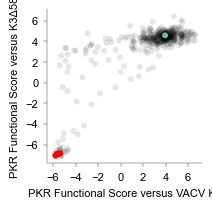

Pearson correlation coefficient: 0.8119579142716559
Spearman correlation coefficient: 0.5730488258182102


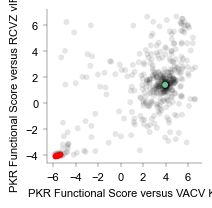

Pearson correlation coefficient: 0.5754406024508143
Spearman correlation coefficient: 0.4088304945532593


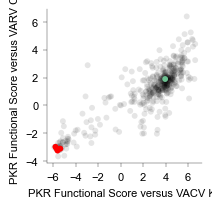

Pearson correlation coefficient: 0.8595896317687849
Spearman correlation coefficient: 0.7679881832407057


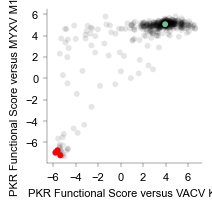

Pearson correlation coefficient: 0.7931881296643748
Spearman correlation coefficient: 0.5549725114960101


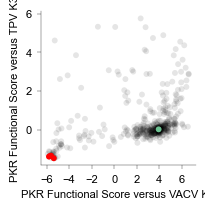

Pearson correlation coefficient: 0.29344225719448513
Spearman correlation coefficient: 0.4853652943398263


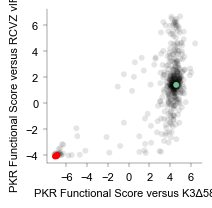

Pearson correlation coefficient: 0.6457375856789305
Spearman correlation coefficient: 0.4268144810757987


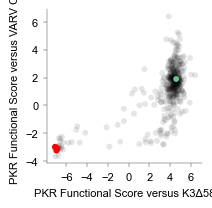

Pearson correlation coefficient: 0.7104769483310451
Spearman correlation coefficient: 0.4954672446147113


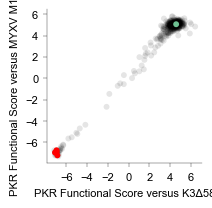

Pearson correlation coefficient: 0.9884593405290533
Spearman correlation coefficient: 0.5997465481993081


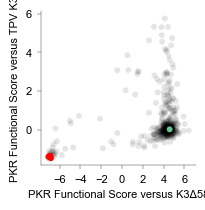

Pearson correlation coefficient: 0.2989812665341794
Spearman correlation coefficient: 0.2894028369814805


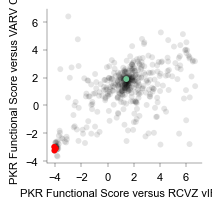

Pearson correlation coefficient: 0.6058135531120122
Spearman correlation coefficient: 0.481353081889962


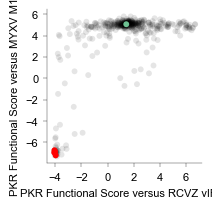

Pearson correlation coefficient: 0.6235037720754405
Spearman correlation coefficient: 0.29071551047081184


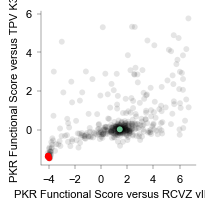

Pearson correlation coefficient: 0.4933915493763845
Spearman correlation coefficient: 0.5357620340893422


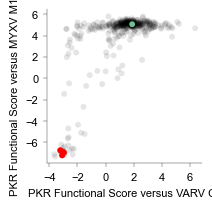

Pearson correlation coefficient: 0.6892110104868183
Spearman correlation coefficient: 0.44566613907924


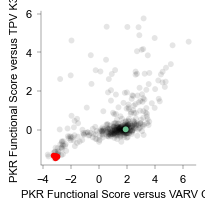

Pearson correlation coefficient: 0.49988616230140737
Spearman correlation coefficient: 0.6105706337643961


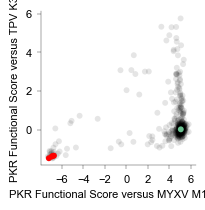

Pearson correlation coefficient: 0.2770207784092451
Spearman correlation coefficient: 0.1953200597133042


In [7]:
# scatterplots of scores by k3 condition
for (k3_x,k3_y,) in k3_combinations:
    # format figure
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .1
    marker_diameter = 3 # 1.75
    
    font = {'family': font_name, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size
    # plot variants
    ax = sns.scatterplot(
        data=temp_df,
        x=k3_x,
        y=k3_y,
        color='black',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=alpha_val
    )
    
    # plot wt 
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "WT"'),
        x=k3_x,
        y=k3_y,
        color='#6dc091',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )

    # average of the nonsense mutants
    #df1 = temp_df.query('pkr_type == "Nonsense"')
    #cols = ['K3L-Null', 'K3L-WT','K3L-H47R']
    #df1 = df1.groupby('pkr_type')[cols].mean().reset_index()
    
    # plot nonsense mutations
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "Nonsense"'),
        x=k3_x,
        y=k3_y,
        color='red',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )
    
    
    # Set x and y limits
    #ax.set_xlim(-7, 8)
    #ax.set_ylim(-9, 8)
    
    # Dashed null cutoff line
    hline = -3
    #ax.axhline(hline, color='red', linestyle='--', linewidth=.75, alpha=1)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)
    
    # Set font properties for axis labels
    ax.set_xlabel(f'PKR Functional Score versus {k3_x}', fontsize=font_size, fontname=font_name)
    ax.set_ylabel(f'PKR Functional Score versus {k3_y}', fontsize=font_size, fontname=font_name)
    
    # Set tick marks and labels every 5 units
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    
    # save plot
    plot_name = f'scatter_x-{k3_x}_y-{k3_y}.svg'
    output_file = os.path.join(save_dir, plot_name)
    plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)
    plt.show()

    # Calculate Pearson correlation
    pearson_corr, _ = pearsonr(temp_df[k3_x], temp_df[k3_y])
    print("Pearson correlation coefficient:", pearson_corr)
    
    # Calculate Spearman correlation
    spearman_corr, _ = spearmanr(temp_df[k3_x], temp_df[k3_y])
    print("Spearman correlation coefficient:", spearman_corr)

In [7]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pkr         430 non-null    object 
 1   pkr_type    430 non-null    object 
 2   site        430 non-null    float64
 3   wt_cat      430 non-null    object 
 4   var_cat     430 non-null    object 
 5   K3Δ58       430 non-null    float64
 6   MYXV M156R  430 non-null    float64
 7   RCVZ vIF2α  430 non-null    float64
 8   TPV K3      430 non-null    float64
 9   VACV K3     430 non-null    float64
 10  VARV C3     430 non-null    float64
dtypes: float64(7), object(4)
memory usage: 37.1+ KB


In [9]:
sites = [379,486,490]
temp_df[temp_df['site'].isin(sites)]

k3,pkr,pkr_type,site,wt_cat,var_cat,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3
26,PKR-D486A,Variant,486.0,Negative Charge,Non-Polar,3.788159,5.066135,1.361969,0.227888,5.361054,2.098695
27,PKR-D486E,Variant,486.0,Negative Charge,Negative Charge,4.673586,5.223987,3.167169,0.181138,5.375574,2.357028
28,PKR-D486G,Variant,486.0,Negative Charge,Unique,4.248201,5.104060,2.652425,0.054533,3.883676,2.884902
29,PKR-D486H,Variant,486.0,Negative Charge,Positive Charge,3.905790,5.049106,0.543177,0.570230,5.339546,2.638013
30,PKR-D486N,Variant,486.0,Negative Charge,Polar-Neutral,4.308170,4.838620,-1.243477,-0.348810,2.107499,0.043335
31,PKR-D486V,Variant,486.0,Negative Charge,Non-Polar,3.835808,4.516261,0.623196,0.550037,5.389387,2.126738
32,PKR-D486Y,Variant,486.0,Negative Charge,Aromatic,3.570834,4.974091,-2.436922,0.108015,0.943566,0.251346
72,PKR-E379A,Variant,379.0,Negative Charge,Non-Polar,5.276706,4.930964,1.271916,0.307296,5.289743,2.513682
73,PKR-E379D,Variant,379.0,Negative Charge,Negative Charge,4.298987,5.144438,-0.953649,-0.366450,1.762227,-1.517760
74,PKR-E379G,Variant,379.0,Negative Charge,Unique,5.921267,5.213652,2.687787,0.676919,5.495756,3.415085


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


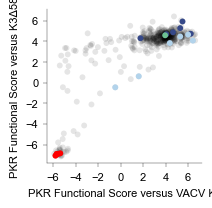

/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


Pearson correlation coefficient: 0.8119579142716559
Spearman correlation coefficient: 0.5730488258182102


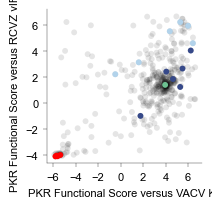

Pearson correlation coefficient: 0.5754406024508143
Spearman correlation coefficient: 0.4088304945532593


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


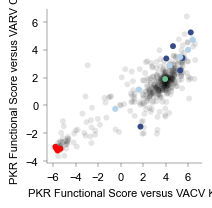

Pearson correlation coefficient: 0.8595896317687849
Spearman correlation coefficient: 0.7679881832407057


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


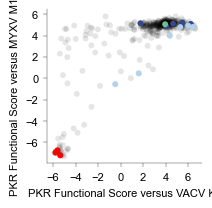

Pearson correlation coefficient: 0.7931881296643748
Spearman correlation coefficient: 0.5549725114960101


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


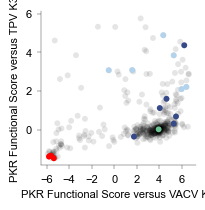

Pearson correlation coefficient: 0.29344225719448513
Spearman correlation coefficient: 0.4853652943398263


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


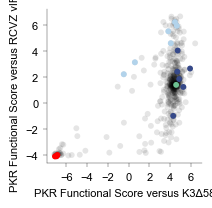

Pearson correlation coefficient: 0.6457375856789305
Spearman correlation coefficient: 0.4268144810757987


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


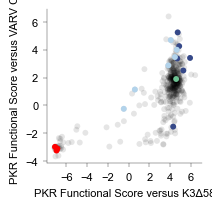

Pearson correlation coefficient: 0.7104769483310451
Spearman correlation coefficient: 0.4954672446147113


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


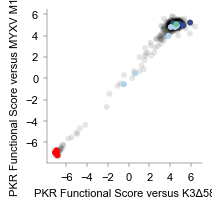

Pearson correlation coefficient: 0.9884593405290533
Spearman correlation coefficient: 0.5997465481993081


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


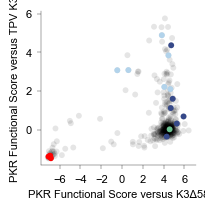

Pearson correlation coefficient: 0.2989812665341794
Spearman correlation coefficient: 0.2894028369814805


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


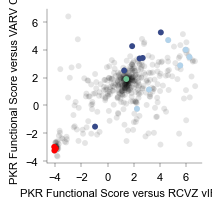

Pearson correlation coefficient: 0.6058135531120122
Spearman correlation coefficient: 0.481353081889962


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


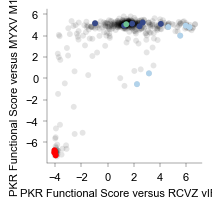

Pearson correlation coefficient: 0.6235037720754405
Spearman correlation coefficient: 0.29071551047081184


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


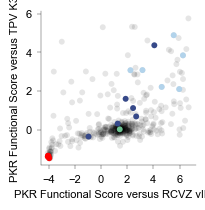

Pearson correlation coefficient: 0.4933915493763845
Spearman correlation coefficient: 0.5357620340893422


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


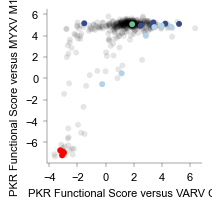

Pearson correlation coefficient: 0.6892110104868183
Spearman correlation coefficient: 0.44566613907924


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


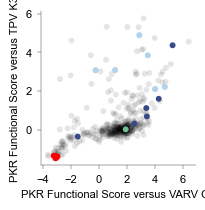

Pearson correlation coefficient: 0.49988616230140737
Spearman correlation coefficient: 0.6105706337643961


/tmp/ipykernel_4109669/827902752.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_df['site_color'] = site_df['site'].map(site_colors)


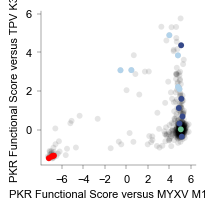

Pearson correlation coefficient: 0.2770207784092451
Spearman correlation coefficient: 0.1953200597133042


In [53]:
# try overlaying sites: E379, D486, and E490

# figure save directory
save_dir = "../../img/k3-conditions/sites/"
os.makedirs(save_dir, exist_ok=True)

sites = [379,490]
#site_colors = {379:"#F39829", 486:"#D787A1", 490:"#4A180D"}
site_colors = {379:"#364989", 490:"#B2D3EB"}

# scatterplots of scores by k3 condition
for (k3_x,k3_y,) in k3_combinations:
    # format figure
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .1
    marker_diameter = 3 # 1.75
    
    font = {'family': font_name, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size
    # plot variants
    ax = sns.scatterplot(
        data=temp_df,
        x=k3_x,
        y=k3_y,
        color='black',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=alpha_val,
        zorder=0
    )
    
    # plot wt 
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "WT"'),
        x=k3_x,
        y=k3_y,
        color='#6dc091',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1,
        zorder=3
    )

    # average of the nonsense mutants
    #df1 = temp_df.query('pkr_type == "Nonsense"')
    #cols = ['K3L-Null', 'K3L-WT','K3L-H47R']
    #df1 = df1.groupby('pkr_type')[cols].mean().reset_index()
    
    # plot nonsense mutations
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "Nonsense"'),
        x=k3_x,
        y=k3_y,
        color='red',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1,
        zorder=3
    )

    site_df = temp_df[temp_df['site'].isin(sites)]
    site_df['site_color'] = site_df['site'].map(site_colors)

    # plot specific sites
    ax = sns.scatterplot(
        data=site_df,
        x=k3_x,
        y=k3_y,
        hue='site',
        palette=site_colors,
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1,
        zorder=2
    )
    
    
    # Set x and y limits
    #ax.set_xlim(-7, 8)
    #ax.set_ylim(-9, 8)
    
    # Dashed null cutoff line
    hline = -3
    #ax.axhline(hline, color='red', linestyle='--', linewidth=.75, alpha=1)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)
    
    # Set font properties for axis labels
    ax.set_xlabel(f'PKR Functional Score versus {k3_x}', fontsize=font_size, fontname=font_name)
    ax.set_ylabel(f'PKR Functional Score versus {k3_y}', fontsize=font_size, fontname=font_name)
    
    # Set tick marks and labels every 5 units
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    
    # save plot
    plot_name = f'scatter_x-{k3_x}_y-{k3_y}_sites-379-490.svg'
    output_file = os.path.join(save_dir, plot_name)
    plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)
    plt.show()

    # Calculate Pearson correlation
    pearson_corr, _ = pearsonr(temp_df[k3_x], temp_df[k3_y])
    print("Pearson correlation coefficient:", pearson_corr)
    
    # Calculate Spearman correlation
    spearman_corr, _ = spearmanr(temp_df[k3_x], temp_df[k3_y])
    print("Spearman correlation coefficient:", spearman_corr)

In [52]:
site_colors = {379:"#364989", 486:"#65A7D3", 490:"#B2D3EB"} # dark to light
temp_df[temp_df['site'].isin(sites)].sort_values('VACV K3', ascending=False).head(20)

,pkr,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3,pkr_type,site,wt_cat,var_cat
558,PKR-E490G,4.069260,4.799001,4.636581,2.206754,6.415437,4.695842,Variant,490.0,Negative Charge,Unique
450,PKR-E379K,4.730075,5.086183,4.073862,4.362405,6.228106,5.249272,Variant,379.0,Negative Charge,Positive Charge
570,PKR-E490Q,4.651119,4.929611,5.974804,2.093585,5.993536,4.003839,Variant,490.0,Negative Charge,Polar-Neutral
444,PKR-E379G,5.921267,5.213652,2.687787,0.676919,5.495756,3.415085,Variant,379.0,Negative Charge,Unique
186,PKR-D486V,3.835808,4.516261,0.623196,0.550037,5.389387,2.126738,Variant,486.0,Negative Charge,Non-Polar
162,PKR-D486E,4.673586,5.223987,3.167169,0.181138,5.375574,2.357028,Variant,486.0,Negative Charge,Negative Charge
156,PKR-D486A,3.788159,5.066135,1.361969,0.227888,5.361054,2.098695,Variant,486.0,Negative Charge,Non-Polar
174,PKR-D486H,3.905790,5.049106,0.543177,0.570230,5.339546,2.638013,Variant,486.0,Negative Charge,Positive Charge
546,PKR-E490A,4.467777,4.788948,6.262130,3.841703,5.295059,3.480012,Variant,490.0,Negative Charge,Non-Polar
432,PKR-E379A,5.276706,4.930964,1.271916,0.307296,5.289743,2.513682,Variant,379.0,Negative Charge,Non-Polar


In [6]:
cols = ['RCVZ vIF2α', 'TPV K3', 'VACV K3', 'VARV C3']
less_cols = ['RCVZ vIF2α', 'VACV K3', 'VARV C3']
temp_df['auc_mean_rank'] = temp_df[cols].rank().sum(axis=1)
temp_df['auc_mean_rank_less'] = temp_df[less_cols].rank().sum(axis=1)

temp_df.sort_values('auc_mean_rank', ascending=False).head(50)['site'].value_counts()

site
480.0    5
379.0    4
490.0    4
491.0    4
485.0    4
484.0    4
493.0    4
378.0    4
382.0    3
385.0    3
495.0    2
383.0    2
486.0    1
506.0    1
375.0    1
483.0    1
488.0    1
487.0    1
489.0    1
Name: count, dtype: int64

In [7]:
temp_df.sort_values('auc_mean_rank_less', ascending=False).head(50)['site'].value_counts()

site
480.0    5
484.0    4
490.0    4
385.0    4
491.0    4
378.0    4
493.0    4
506.0    3
485.0    3
379.0    3
382.0    2
383.0    2
487.0    1
483.0    1
488.0    1
495.0    1
486.0    1
381.0    1
482.0    1
375.0    1
Name: count, dtype: int64

In [33]:
temp_df.sort_values('auc_mean_rank', ascending=False).head(20)['var_cat'].value_counts()

var_cat
Positive Charge    6
Polar-Neutral      4
Unique             4
Non-Polar          4
Negative Charge    2
Name: count, dtype: int64

In [34]:
temp_df.sort_values('auc_mean_rank', ascending=False).head(20)['wt_cat'].value_counts()

wt_cat
Negative Charge    6
Polar-Neutral      6
Non-Polar          4
Positive Charge    3
Aromatic           1
Name: count, dtype: int64

In [37]:
temp_df.sort_values('auc_mean_rank', ascending=False).head(20)['site'].value_counts()

site
484.0    3
490.0    3
491.0    3
382.0    2
485.0    2
379.0    1
495.0    1
487.0    1
488.0    1
375.0    1
480.0    1
483.0    1
Name: count, dtype: int64

In [36]:
temp_df.sort_values('auc_mean_rank', ascending=False).head(20)

k3,pkr,pkr_type,site,wt_cat,var_cat,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3,auc_mean_rank
333,PKR-R382K,Variant,382.0,Positive Charge,Positive Charge,4.846408,5.269403,5.760235,3.386429,5.681640,5.124103,1667.0
409,PKR-V484E,Variant,484.0,Non-Polar,Negative Charge,4.281422,4.992329,6.029136,2.992007,5.945100,4.538548,1667.0
75,PKR-E379K,Variant,379.0,Negative Charge,Positive Charge,4.730075,5.086183,4.073862,4.362405,6.228106,5.249272,1662.0
130,PKR-F495S,Variant,495.0,Aromatic,Polar-Neutral,4.565299,4.992040,5.078144,2.541337,6.424590,4.230083,1647.0
390,PKR-T487S,Variant,487.0,Polar-Neutral,Polar-Neutral,4.134394,4.740701,6.519942,4.165881,5.468388,3.153612,1645.0
95,PKR-E490Q,Variant,490.0,Negative Charge,Polar-Neutral,4.651119,4.929611,5.974804,2.093585,5.993536,4.003839,1644.0
93,PKR-E490G,Variant,490.0,Negative Charge,Unique,4.069260,4.799001,4.636581,2.206754,6.415437,4.695842,1643.0
392,PKR-T491I,Variant,491.0,Polar-Neutral,Non-Polar,4.377415,4.863790,6.180822,2.929937,5.402575,3.589216,1639.0
91,PKR-E490A,Variant,490.0,Negative Charge,Non-Polar,4.467777,4.788948,6.262130,3.841703,5.295059,3.480012,1637.0
7,PKR-C485G,Variant,485.0,Polar-Neutral,Unique,4.424370,4.710262,6.260226,2.056154,5.669846,3.378562,1629.0


In [47]:
sites = [484,490,491,382,485]
temp_df.sort_values('auc_mean_rank', ascending=False).head(20).query('site in @sites').sort_values('site')

k3,pkr,pkr_type,site,wt_cat,var_cat,K3Δ58,MYXV M156R,RCVZ vIF2α,TPV K3,VACV K3,VARV C3,auc_mean_rank
333,PKR-R382K,Variant,382.0,Positive Charge,Positive Charge,4.846408,5.269403,5.760235,3.386429,5.681640,5.124103,1667.0
332,PKR-R382I,Variant,382.0,Positive Charge,Non-Polar,5.316933,5.059452,5.529949,2.353124,4.728519,3.545482,1574.0
409,PKR-V484E,Variant,484.0,Non-Polar,Negative Charge,4.281422,4.992329,6.029136,2.992007,5.945100,4.538548,1667.0
410,PKR-V484G,Variant,484.0,Non-Polar,Unique,4.737857,5.163767,5.564943,1.460585,5.515763,4.334467,1612.0
408,PKR-V484A,Variant,484.0,Non-Polar,Non-Polar,4.533884,4.722719,6.085492,1.120471,5.393511,3.970851,1595.0
7,PKR-C485G,Variant,485.0,Polar-Neutral,Unique,4.424370,4.710262,6.260226,2.056154,5.669846,3.378562,1629.0
8,PKR-C485R,Variant,485.0,Polar-Neutral,Positive Charge,4.593429,4.699070,6.512692,1.556518,5.501437,3.241806,1611.0
95,PKR-E490Q,Variant,490.0,Negative Charge,Polar-Neutral,4.651119,4.929611,5.974804,2.093585,5.993536,4.003839,1644.0
93,PKR-E490G,Variant,490.0,Negative Charge,Unique,4.069260,4.799001,4.636581,2.206754,6.415437,4.695842,1643.0
91,PKR-E490A,Variant,490.0,Negative Charge,Non-Polar,4.467777,4.788948,6.262130,3.841703,5.295059,3.480012,1637.0


In [11]:
temp_df.sort_values('TPV K3', ascending=False).head(20)['site'].value_counts()

site
490.0    4
382.0    4
453.0    3
488.0    2
454.0    2
489.0    1
452.0    1
379.0    1
487.0    1
495.0    1
Name: count, dtype: int64